In [1]:
import numpy as np 

# Sätt ert gruppnummer här (23). 

gruppnummer = 23

 

rng = np.random.default_rng(gruppnummer) 

 

#    Variation: upp till ± 3 minuter runt 42 beroende på gruppnummer 

loc_bas = 42.0 

loc = loc_bas + (gruppnummer % 7 - 3) * 0.5 

 

scale_bas = 4.5 

scale = scale_bas + (gruppnummer % 5 - 2) * 0.3 

 

# Säkerställ att scale aldrig blir för liten 

scale = max(scale, 1.0) 

 

print(f"Grupp {gruppnummer}: loc = {loc:.2f}, scale = {scale:.2f}") 

 

# Generera leveranstider (minuter) från N(loc, scale) 

leveranstider = rng.normal(loc=loc, scale=scale, size=30) 
leveranstider = np.round(leveranstider, 1) 

 
# Klipp bort eventuella negativa eller orimligt små tider 

leveranstider = np.clip(leveranstider, a_min=1.0, a_max=None) 

print(leveranstider) 

Grupp 23: loc = 41.50, scale = 4.80
[44.2 42.5 41.2 30.4 43.6 31.3 45.9 44.4 45.5 45.5 42.9 38.9 40.  48.7
 38.7 40.4 38.  39.  40.  42.7 40.1 39.8 38.5 41.9 35.  41.8 47.8 37.8
 41.3 55. ]


In [2]:
# variabel leveranstider  innehåller kvantitativ numerisk data. Den mäter tid i minuter.

# Nu ska vi göra en sammanfattande beskrivning av datan.
#vi använder numpy för att beräkna medelvärde, median och standardavvikelse.
def data_summary(leveranstider):
    medelvärde = np.mean(leveranstider)
    median = np.median(leveranstider)
    standardavvikelse = np.std(leveranstider, ddof=1)# ddof=1 för stickprovsstandardavvikelse
    n = len(leveranstider)  

    print("medelvärde: ", medelvärde)
    print("median: ", median)
    print("standardavvikelse: ", standardavvikelse)
    print("antal observationer: ", n)

print("Sammanfattning av leveranstider:")
data_summary(leveranstider)    
# nu har medelvärde vi x=41.42
# och mittersta värdet (median) är 41.25
# och standardavvikelsen S= 4.86


Sammanfattning av leveranstider:
medelvärde:  41.426666666666655
median:  41.25
standardavvikelse:  4.862660924264391
antal observationer:  30


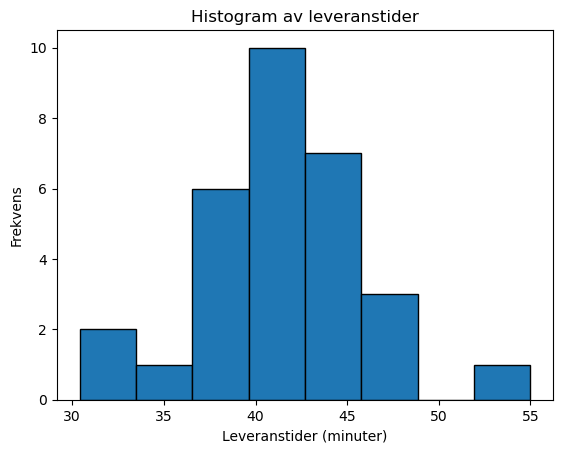

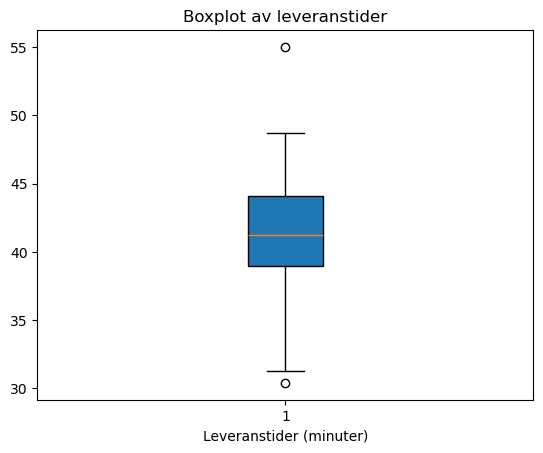

In [3]:
# Nu ska vi göra en diagram för att visa datan. Vi använder matplotlib för att skapa en histogram och en boxplot.


import matplotlib.pyplot as plt
# vi gör först histogram för att visa hur data fördelar sig.
def data_histogram(leveranstider):   
    plt.hist(leveranstider, bins=8, edgecolor='black')
    plt.xlabel("Leveranstider (minuter)")
    plt.ylabel("Frekvens")
    plt.title("Histogram av leveranstider")
    plt.show()


data_histogram(leveranstider)

# Nu gör vi en boxplot, boxplot är bra för att upptäcka median, spridning och eventuella outliers i datan.
def data_boxplot(leveranstider):
    plt.boxplot(leveranstider, patch_artist=True)
    plt.xlabel("Leveranstider (minuter)")
    plt.title("Boxplot av leveranstider")
    plt.show()

data_boxplot(leveranstider)

## vi ser i boxplot median är ca 41.25 och det finns några outliers som är över 50 minuter.


# H0 det finns ingen förändring i leveranstiderna
# HA det finns en förändring i leveranstiderna

In [ ]:
from scipy import stats
from scipy.stats import ttest_1samp
import numpy as np

## funktionen ttest_1samp tar två argument: datan (leveranstider) 
# och det hypotetiska medelvärdet (popmean) som vi vill jämföra med.
#  I det här fallet är popmean=42, vilket är det hypotetiska medelvärdet/ kända populationenvärdet.

# H0​:μ=42 
result = ttest_1samp(leveranstider, popmean=42) 
## jag avrundade värderna till 3 decimaler för att göra det mer läsbart.
print("t-statistik: ", result.statistic.round(3))
print("p-värde: ", result.pvalue.round(3))

#p-värde(tvåsidigt):0,523 




medelvärde = np.mean(leveranstider)
median = np.median(leveranstider)
standardavvikelse = np.std(leveranstider, ddof=1)# ddof=1 för stickprovsstandardavvikelse
n = len(leveranstider)  

# beräkna 95% konfidensintervall för medelvärdet 
ci=stats.t.interval(0.95, df=n-1, loc=medelvärde, scale=standardavvikelse/np.sqrt(n))
print("95% konfidensintervall: ", np.round(ci, 3))

## tolkning
# vi jämförde p-värdet med signifikansnivån  α=0.05 
# eftersom 0.523 > 0.05 så kan vi inte förkasta nollhypotesen H0​.
#  Det betyder att det inte finns tillräckligt med bevis i datan för att säga att det genomsnittliga levernastiden har förändrats. 



# ----- ATT TÄNKA PÅ -----
# Skillnaden är ganska liten: 42 - 41.43 = 0.57 minuter./ ca 34 sekunder..
# En skillnad på 0.57 minuter kanske inte spelar så stor roll i logistisk verksamhet.
# Därför, även om skillnaden hade varit statistiskt signifikant,
# behöver den inte nödvändigtvis vara praktiskt betydelsefull.






    



t-statistik:  -0.646
p-värde:  0.523
95% konfidensintervall:  [39.611 43.242]
